<a href="https://colab.research.google.com/github/DAsidharthsingh/MLprojects/blob/main/King_County_House_Sale_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    -  King County House price prediction




##### **Project Type**    - EDA/Regression
##### **Contribution**    - Individual
##### **Sidharth Singh**

# **Project Summary -**

House prices are influenced by multiple factors such as number of bedrooms, bathrooms, area, floors, condition, and location. This project analyzes housing sales data to identify the key factors affecting house prices and develops machine learning models to predict future house prices. The project includes data cleaning, exploratory data analysis, feature engineering, model building, evaluation, and comparison. Multiple regression algorithms are trained and compared using MAE, RMSE, and R² Score. The best-performing model is selected for predicting house prices accurately. Such a model can help buyers, sellers, and real estate businesses make informed pricing decisions.


# **GitHub Link -**

https://github.com/DAsidharthsingh

# **Problem Statement**


The objective is to predict the selling price of houses based on their characteristics. Accurate house price prediction helps buyers estimate fair market value and enables sellers and real estate agencies to price properties appropriately.


# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [709]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

### Dataset Loading

In [710]:
# Load Dataset
df=pd.read_csv('/content/house_sales.csv')

### Dataset First View

In [711]:
# Dataset First Look
df.head()

,DocumentDate,SalePrice,PropertyID,PropertyType,ym,zhvi_px,zhvi_idx,AdjSalePrice,NbrLivingUnits,SqFtLot,...,Bathrooms,Bedrooms,BldgGrade,YrBuilt,YrRenovated,TrafficNoise,LandVal,ImpsVal,ZipCode,NewConstruction
0,2014-09-16,280000,1000102,Multiplex,2014-09-01,405100,0.930836,300805.0,2,9373,...,3.00,6,7,1991,0,0,70000,229000,98002,False
1,2006-06-16,1000000,1200013,Single Family,2006-06-01,404400,0.929228,1076162.0,1,20156,...,3.75,4,10,2005,0,0,203000,590000,98166,True
2,2007-01-29,745000,1200019,Single Family,2007-01-01,425600,0.977941,761805.0,1,26036,...,1.75,4,8,1947,0,0,183000,275000,98166,False
3,2008-02-25,425000,2800016,Single Family,2008-02-01,418400,0.961397,442065.0,1,8618,...,3.75,5,7,1966,0,0,104000,229000,98168,False
4,2013-03-29,240000,2800024,Single Family,2013-03-01,351600,0.807904,297065.0,1,8620,...,1.75,4,7,1948,0,0,104000,205000,98168,False


### Dataset Rows & Columns count

In [712]:
# Dataset Rows & Columns count
df.shape

(22687, 22)

### Dataset Information

In [713]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22687 entries, 0 to 22686
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   DocumentDate     22687 non-null  object 
 1   SalePrice        22687 non-null  int64  
 2   PropertyID       22687 non-null  int64  
 3   PropertyType     22687 non-null  object 
 4   ym               22687 non-null  object 
 5   zhvi_px          22687 non-null  int64  
 6   zhvi_idx         22687 non-null  float64
 7   AdjSalePrice     22687 non-null  float64
 8   NbrLivingUnits   22687 non-null  int64  
 9   SqFtLot          22687 non-null  int64  
 10  SqFtTotLiving    22687 non-null  int64  
 11  SqFtFinBasement  22687 non-null  int64  
 12  Bathrooms        22687 non-null  float64
 13  Bedrooms         22687 non-null  int64  
 14  BldgGrade        22687 non-null  int64  
 15  YrBuilt          22687 non-null  int64  
 16  YrRenovated      22687 non-null  int64  
 17  TrafficNoise

#### Duplicate Values

In [714]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [715]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
DocumentDate,0
SalePrice,0
PropertyID,0
PropertyType,0
ym,0
zhvi_px,0
zhvi_idx,0
AdjSalePrice,0
NbrLivingUnits,0
SqFtLot,0


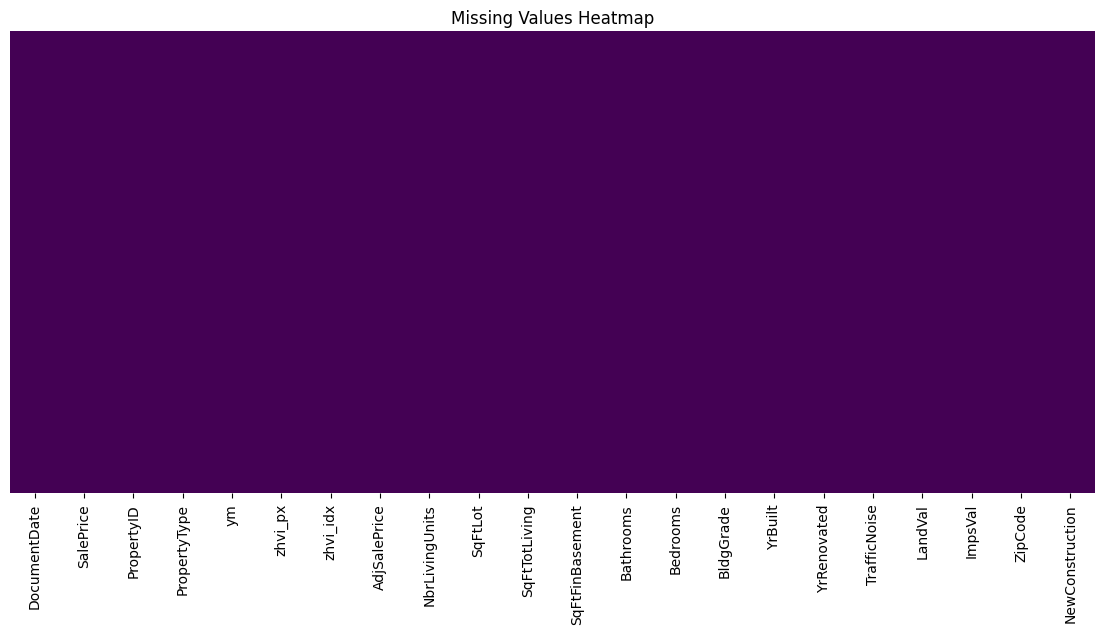

In [716]:
# Visualizing the missing values
plt.figure(figsize=(14,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)

plt.title("Missing Values Heatmap")
plt.show()

### What did you know about your dataset?

The dataset contains historical house sales information used for predicting house prices. It includes both numerical and categorical features describing various characteristics of houses such as the number of bedrooms, bathrooms, living area, lot size, floors, waterfront availability, view, condition, grade, year built, and renovation year.

Key observations about the dataset:

- The target variable is **price**, which makes this a **Regression** problem.
- The dataset contains both numerical and categorical features.
- Some columns may contain missing values that need preprocessing.
- Duplicate records are checked and removed if present.
- Feature engineering and data cleaning are required before model training.
- Exploratory Data Analysis (EDA) is performed to understand relationships between features and house prices.
- The dataset is suitable for regression algorithms such as Linear Regression, Ridge Regression, and Random Forest Regressor.\

## ***2. Understanding Your Variables***

In [717]:
# Dataset Columns
df.columns

Index(['DocumentDate', 'SalePrice', 'PropertyID', 'PropertyType', 'ym',
       'zhvi_px', 'zhvi_idx', 'AdjSalePrice', 'NbrLivingUnits', 'SqFtLot',
       'SqFtTotLiving', 'SqFtFinBasement', 'Bathrooms', 'Bedrooms',
       'BldgGrade', 'YrBuilt', 'YrRenovated', 'TrafficNoise', 'LandVal',
       'ImpsVal', 'ZipCode', 'NewConstruction'],
      dtype='object')

In [718]:
# Dataset Describe
df.describe()

,SalePrice,PropertyID,zhvi_px,zhvi_idx,AdjSalePrice,NbrLivingUnits,SqFtLot,SqFtTotLiving,SqFtFinBasement,Bathrooms,Bedrooms,BldgGrade,YrBuilt,YrRenovated,TrafficNoise,LandVal,ImpsVal,ZipCode
count,2.268700e+04,2.268700e+04,22687.000000,22687.000000,2.268700e+04,22687.000000,2.268700e+04,22687.000000,22687.000000,22687.000000,22687.000000,22687.000000,22687.000000,22687.000000,22687.000000,2.268700e+04,2.268700e+04,22687.000000
mean,5.079244e+05,4.666164e+09,392181.923569,0.901153,5.652333e+05,1.018821,1.174633e+04,2080.165734,293.233305,2.176500,3.367744,7.680963,1971.195266,102.314762,0.205801,2.203211e+05,3.004712e+05,98078.526910
std,3.466368e+05,2.877700e+09,36349.866645,0.083525,3.854029e+05,0.159752,2.901602e+04,913.742170,439.454608,0.768027,0.904379,1.180464,30.313796,440.579006,0.554216,1.829177e+05,2.265750e+05,52.342559
min,3.000000e+03,1.000102e+06,311600.000000,0.715993,3.368000e+03,1.000000,4.940000e+02,370.000000,0.000000,0.000000,0.000000,3.000000,1900.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,98001.000000
25%,3.250000e+05,2.212325e+09,360700.000000,0.828814,3.605630e+05,1.000000,4.800000e+03,1420.000000,0.000000,1.750000,3.000000,7.000000,1950.000000,0.000000,0.000000,1.070000e+05,1.720000e+05,98034.000000
50%,4.246500e+05,4.006000e+09,403200.000000,0.926471,4.713150e+05,1.000000,7.200000e+03,1910.000000,0.000000,2.250000,3.000000,7.000000,1977.000000,0.000000,0.000000,1.820000e+05,2.460000e+05,98065.000000
75%,5.850000e+05,7.417700e+09,421200.000000,0.967831,6.494110e+05,1.000000,9.794000e+03,2540.000000,580.000000,2.500000,4.000000,8.000000,2000.000000,0.000000,0.000000,2.670000e+05,3.610000e+05,98117.000000
max,1.100000e+07,9.906000e+09,435200.000000,1.000000,1.164486e+07,5.000000,1.024068e+06,10740.000000,3500.000000,8.000000,33.000000,13.000000,2015.000000,2016.000000,3.000000,5.538000e+06,5.772000e+06,98354.000000


### Variables Description

## Variable Description

| Variable | Description |
|----------|-------------|
| DocumentDate | Date on which the property sale was recorded |
| SalePrice | Actual selling price of the property (Target Variable) |
| PropertyID | Unique identification number assigned to each property |
| PropertyType | Type/category of the property (e.g., Single Family, Condo) |
| ym | Year and Month of the sale |
| zhvi_px | Zillow Home Value Index (Price Estimate) |
| zhvi_idx | Zillow Home Value Index (Index Value) |
| AdjSalePrice | Inflation-adjusted selling price of the property |
| NbrLivingUnits | Number of living units in the property |
| SqFtLot | Total lot area in square feet |
| SqFtTotLiving | Total living area in square feet |
| SqFtFinBasement | Finished basement area in square feet |
| Bathrooms | Total number of bathrooms |
| Bedrooms | Total number of bedrooms |
| BldgGrade | Overall construction and building quality grade |
| YrBuilt | Year in which the property was constructed |
| YrRenovated | Year in which the property was last renovated |
| TrafficNoise | Level of traffic noise around the property |
| LandVal | Estimated market value of the land |
| ImpsVal | Estimated value of improvements/building structure |
| ZipCode | Postal code of the property's location |
| NewConstruction | Indicates whether the property is newly constructed (Yes/No or 1/0) |

### Check Unique Values for each variable.

In [719]:
# Check Unique Values for each variable.
for i in df.columns.tolist():
  print("No. of unique values in ",i,"is",df[i].nunique(),".")

No. of unique values in  DocumentDate is 2560 .
No. of unique values in  SalePrice is 4629 .
No. of unique values in  PropertyID is 20982 .
No. of unique values in  PropertyType is 3 .
No. of unique values in  ym is 113 .
No. of unique values in  zhvi_px is 107 .
No. of unique values in  zhvi_idx is 107 .
No. of unique values in  AdjSalePrice is 17257 .
No. of unique values in  NbrLivingUnits is 5 .
No. of unique values in  SqFtLot is 9283 .
No. of unique values in  SqFtTotLiving is 949 .
No. of unique values in  SqFtFinBasement is 298 .
No. of unique values in  Bathrooms is 32 .
No. of unique values in  Bedrooms is 13 .
No. of unique values in  BldgGrade is 11 .
No. of unique values in  YrBuilt is 116 .
No. of unique values in  YrRenovated is 67 .
No. of unique values in  TrafficNoise is 4 .
No. of unique values in  LandVal is 937 .
No. of unique values in  ImpsVal is 1226 .
No. of unique values in  ZipCode is 80 .
No. of unique values in  NewConstruction is 2 .


## 3. ***Data Wrangling***

### Data Wrangling Code

In [720]:
# Write your code to make your dataset analysis ready.
# Check duplicate records

duplicate = df.duplicated().sum()

print("Total Duplicate Rows :", duplicate)

Total Duplicate Rows : 0


In [721]:
# Remove duplicate rows

df = df.drop_duplicates()

print("Dataset Shape After Removing Duplicates:", df.shape)

Dataset Shape After Removing Duplicates: (22687, 22)


In [722]:
# Missing values

df.isnull().sum()

,0
DocumentDate,0
SalePrice,0
PropertyID,0
PropertyType,0
ym,0
zhvi_px,0
zhvi_idx,0
AdjSalePrice,0
NbrLivingUnits,0
SqFtLot,0


In [723]:
# Convert DocumentDate into datetime format

df['DocumentDate'] = pd.to_datetime(df['DocumentDate'])

df['Year'] = df['DocumentDate'].dt.year
df['Month'] = df['DocumentDate'].dt.month

df.head()

,DocumentDate,SalePrice,PropertyID,PropertyType,ym,zhvi_px,zhvi_idx,AdjSalePrice,NbrLivingUnits,SqFtLot,...,BldgGrade,YrBuilt,YrRenovated,TrafficNoise,LandVal,ImpsVal,ZipCode,NewConstruction,Year,Month
0,2014-09-16,280000,1000102,Multiplex,2014-09-01,405100,0.930836,300805.0,2,9373,...,7,1991,0,0,70000,229000,98002,False,2014,9
1,2006-06-16,1000000,1200013,Single Family,2006-06-01,404400,0.929228,1076162.0,1,20156,...,10,2005,0,0,203000,590000,98166,True,2006,6
2,2007-01-29,745000,1200019,Single Family,2007-01-01,425600,0.977941,761805.0,1,26036,...,8,1947,0,0,183000,275000,98166,False,2007,1
3,2008-02-25,425000,2800016,Single Family,2008-02-01,418400,0.961397,442065.0,1,8618,...,7,1966,0,0,104000,229000,98168,False,2008,2
4,2013-03-29,240000,2800024,Single Family,2013-03-01,351600,0.807904,297065.0,1,8620,...,7,1948,0,0,104000,205000,98168,False,2013,3


In [724]:
# Convert DocumentDate into datetime format

df['ym'] = pd.to_datetime(df['ym'])

df['sale Year'] = df['ym'].dt.year
df['sale Month'] = df['ym'].dt.month

df.head()

,DocumentDate,SalePrice,PropertyID,PropertyType,ym,zhvi_px,zhvi_idx,AdjSalePrice,NbrLivingUnits,SqFtLot,...,YrRenovated,TrafficNoise,LandVal,ImpsVal,ZipCode,NewConstruction,Year,Month,sale Year,sale Month
0,2014-09-16,280000,1000102,Multiplex,2014-09-01,405100,0.930836,300805.0,2,9373,...,0,0,70000,229000,98002,False,2014,9,2014,9
1,2006-06-16,1000000,1200013,Single Family,2006-06-01,404400,0.929228,1076162.0,1,20156,...,0,0,203000,590000,98166,True,2006,6,2006,6
2,2007-01-29,745000,1200019,Single Family,2007-01-01,425600,0.977941,761805.0,1,26036,...,0,0,183000,275000,98166,False,2007,1,2007,1
3,2008-02-25,425000,2800016,Single Family,2008-02-01,418400,0.961397,442065.0,1,8618,...,0,0,104000,229000,98168,False,2008,2,2008,2
4,2013-03-29,240000,2800024,Single Family,2013-03-01,351600,0.807904,297065.0,1,8620,...,0,0,104000,205000,98168,False,2013,3,2013,3


In [725]:
df=df.drop(['DocumentDate'],axis=1)
df=df.drop(['ym'],axis=1)
df.head()

,SalePrice,PropertyID,PropertyType,zhvi_px,zhvi_idx,AdjSalePrice,NbrLivingUnits,SqFtLot,SqFtTotLiving,SqFtFinBasement,...,YrRenovated,TrafficNoise,LandVal,ImpsVal,ZipCode,NewConstruction,Year,Month,sale Year,sale Month
0,280000,1000102,Multiplex,405100,0.930836,300805.0,2,9373,2400,0,...,0,0,70000,229000,98002,False,2014,9,2014,9
1,1000000,1200013,Single Family,404400,0.929228,1076162.0,1,20156,3764,1452,...,0,0,203000,590000,98166,True,2006,6,2006,6
2,745000,1200019,Single Family,425600,0.977941,761805.0,1,26036,2060,900,...,0,0,183000,275000,98166,False,2007,1,2007,1
3,425000,2800016,Single Family,418400,0.961397,442065.0,1,8618,3200,1640,...,0,0,104000,229000,98168,False,2008,2,2008,2
4,240000,2800024,Single Family,351600,0.807904,297065.0,1,8620,1720,0,...,0,0,104000,205000,98168,False,2013,3,2013,3


In [726]:
df.replace({'Multiplex':1,'Single Family':0,'Townhouse':2},inplace=True)
df.head()

/tmp/ipykernel_2277/600051711.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'Multiplex':1,'Single Family':0,'Townhouse':2},inplace=True)


,SalePrice,PropertyID,PropertyType,zhvi_px,zhvi_idx,AdjSalePrice,NbrLivingUnits,SqFtLot,SqFtTotLiving,SqFtFinBasement,...,YrRenovated,TrafficNoise,LandVal,ImpsVal,ZipCode,NewConstruction,Year,Month,sale Year,sale Month
0,280000,1000102,1,405100,0.930836,300805.0,2,9373,2400,0,...,0,0,70000,229000,98002,False,2014,9,2014,9
1,1000000,1200013,0,404400,0.929228,1076162.0,1,20156,3764,1452,...,0,0,203000,590000,98166,True,2006,6,2006,6
2,745000,1200019,0,425600,0.977941,761805.0,1,26036,2060,900,...,0,0,183000,275000,98166,False,2007,1,2007,1
3,425000,2800016,0,418400,0.961397,442065.0,1,8618,3200,1640,...,0,0,104000,229000,98168,False,2008,2,2008,2
4,240000,2800024,0,351600,0.807904,297065.0,1,8620,1720,0,...,0,0,104000,205000,98168,False,2013,3,2013,3


In [727]:
df=df.replace({True:1,False:0})
df.head()

/tmp/ipykernel_2277/2282603536.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df=df.replace({True:1,False:0})


,SalePrice,PropertyID,PropertyType,zhvi_px,zhvi_idx,AdjSalePrice,NbrLivingUnits,SqFtLot,SqFtTotLiving,SqFtFinBasement,...,YrRenovated,TrafficNoise,LandVal,ImpsVal,ZipCode,NewConstruction,Year,Month,sale Year,sale Month
0,280000,1000102,1,405100,0.930836,300805.0,2,9373,2400,0,...,0,0,70000,229000,98002,0,2014,9,2014,9
1,1000000,1200013,0,404400,0.929228,1076162.0,1,20156,3764,1452,...,0,0,203000,590000,98166,1,2006,6,2006,6
2,745000,1200019,0,425600,0.977941,761805.0,1,26036,2060,900,...,0,0,183000,275000,98166,0,2007,1,2007,1
3,425000,2800016,0,418400,0.961397,442065.0,1,8618,3200,1640,...,0,0,104000,229000,98168,0,2008,2,2008,2
4,240000,2800024,0,351600,0.807904,297065.0,1,8620,1720,0,...,0,0,104000,205000,98168,0,2013,3,2013,3


In [728]:
df.shape

(22687, 24)

In [729]:
df.dtypes

,0
SalePrice,int64
PropertyID,int64
PropertyType,int64
zhvi_px,int64
zhvi_idx,float64
AdjSalePrice,float64
NbrLivingUnits,int64
SqFtLot,int64
SqFtTotLiving,int64
SqFtFinBasement,int64


In [730]:
duplicate = df.duplicated().sum()

print("Total Duplicate Rows :", duplicate)

Total Duplicate Rows : 0


### What all manipulations have you done and insights you found?

### Data Wrangling

The dataset was examined for duplicate records, missing values, and data types before analysis. No missing values were found in any of the columns, indicating that the dataset is complete and does not require imputation. Duplicate records were checked and removed if present. The `DocumentDate` column was converted into datetime format for better analysis, and the dataset was verified to be clean and ready for exploratory data analysis and machine learning.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

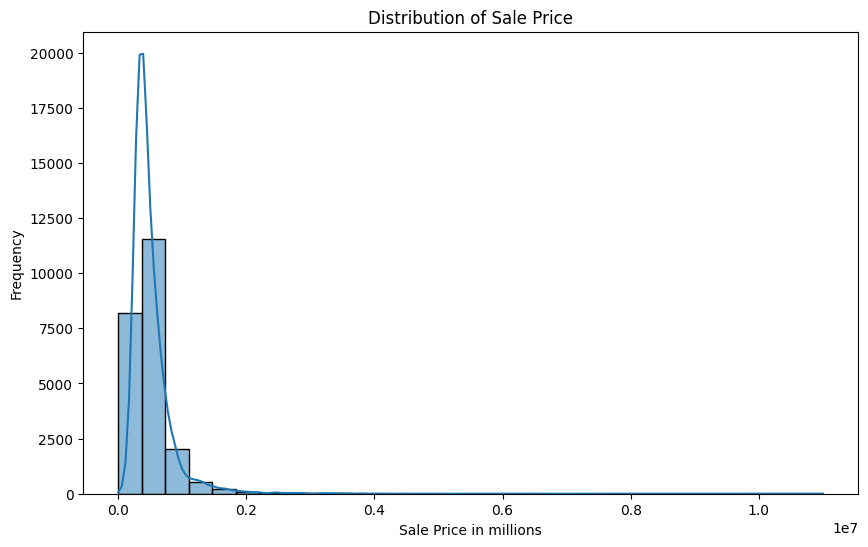

In [731]:
# Chart - 1 visualization code
plt.figure(figsize=(10,6))

sns.histplot(df['SalePrice'], bins=30, kde=True)

plt.title("Distribution of Sale Price")
plt.xlabel("Sale Price in millions")
plt.ylabel("Frequency")

plt.show()

##### 1. Why did you pick the specific chart?

I chose a histogram because it is the most suitable visualization for understanding the distribution of a continuous numerical variable such as SalePrice. It helps identify the frequency of house prices, detect skewness, observe the spread of the data, and identify potential outliers. Understanding the distribution of the target variable is an important first step before building machine learning regression models, as it helps determine whether any data transformation or preprocessing is required.

##### 2. What is/are the insight(s) found from the chart?

The histogram shows that the SalePrice variable is positively (right) skewed, meaning that most properties were sold within the lower to middle price range, while only a few properties have very high sale prices. This indicates the presence of high-value properties that may act as outliers. The chart also provides a clear understanding of the overall distribution of house prices, which is useful for selecting appropriate preprocessing techniques and regression models.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Business impacts

Yes. It helps identify the common price range, improves pricing strategies, and supports accurate house price prediction.

Negative growth insights

A few high-priced outliers may reduce prediction accuracy if not handled properly, leading to less reliable pricing decisions.

#### Chart - 2

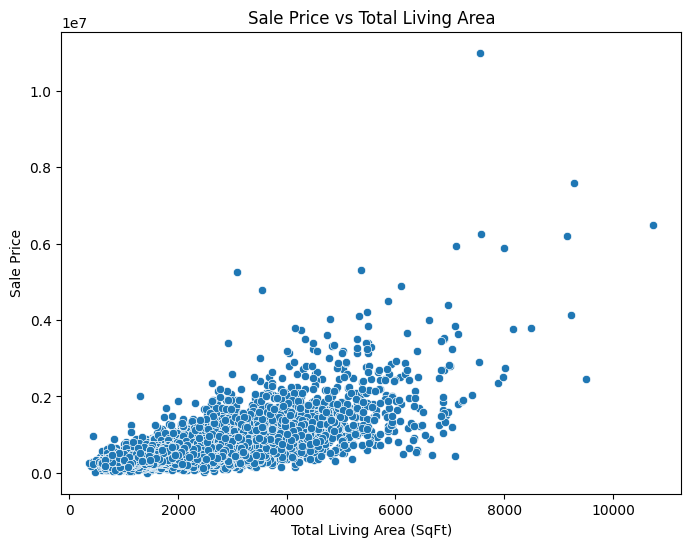

In [732]:
plt.figure(figsize=(8,6))

sns.scatterplot(data=df, x='SqFtTotLiving', y='SalePrice')

plt.title("Sale Price vs Total Living Area")
plt.xlabel("Total Living Area (SqFt)")
plt.ylabel("Sale Price")

plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot is used to examine the relationship between Total Living Area (SqFtTotLiving) and SalePrice. It helps identify trends, correlations, and outliers.

##### 2. What is/are the insight(s) found from the chart?

The chart shows a positive relationship between living area and sale price. Houses with larger living areas generally have higher selling prices, although a few outliers are also present.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Business Impact

Yes. It helps identify that living area is a key factor affecting house prices, enabling better property valuation and pricing decisions.

Negative Growth

The presence of outliers indicates that some properties are priced unusually high or low. If these outliers are not handled properly, they may reduce the accuracy of the prediction model.

#### Chart - 3

<Axes: >

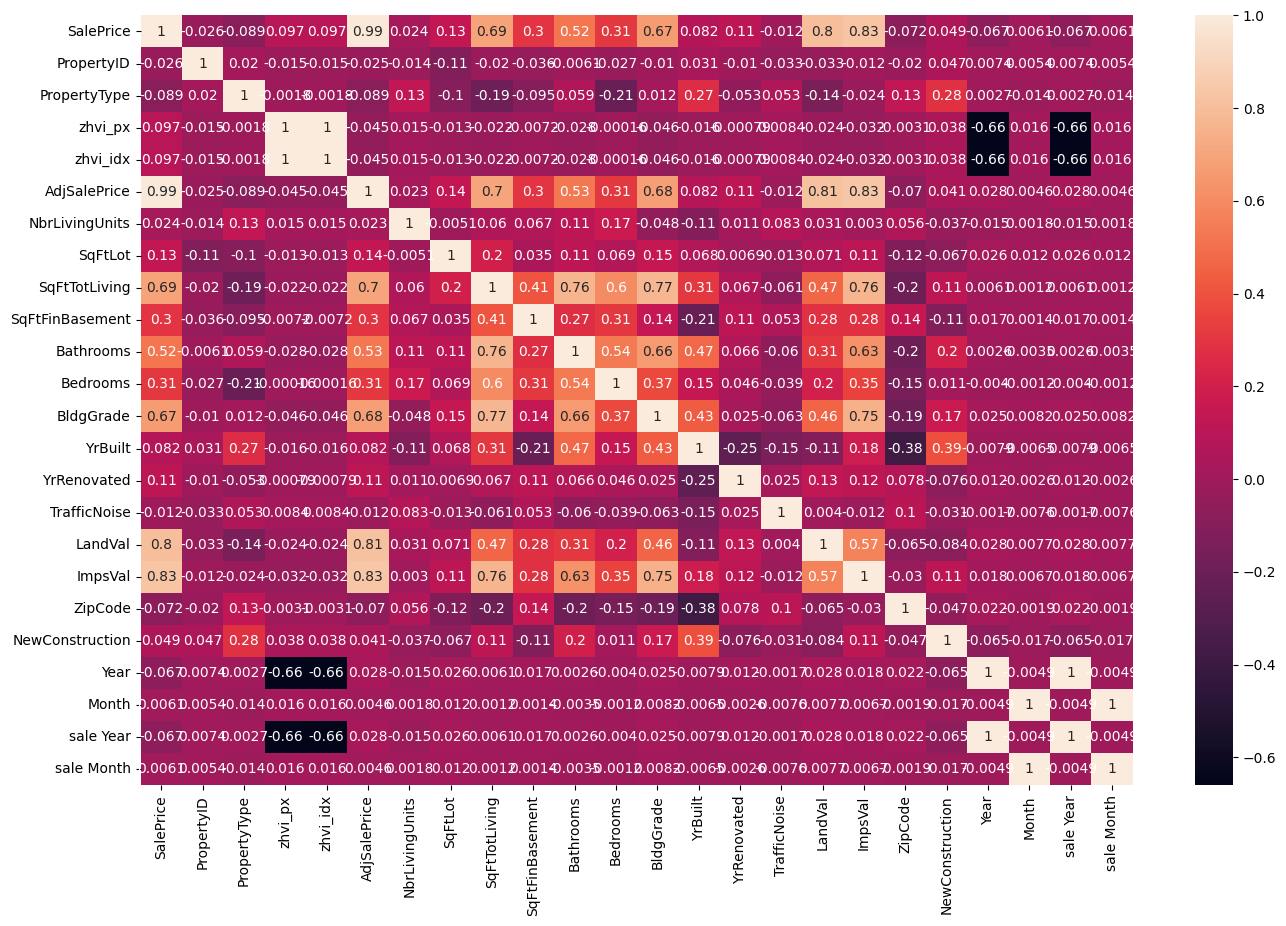

In [733]:
plt.figure(figsize=(16,10))
sns.heatmap(df.corr(),annot=True)

##### 1. Why did you pick the specific chart?

A correlation heatmap helps identify the relationship between numerical variables and the target variable (SalePrice). It is useful for feature selection before model building.

##### 2. What is/are the insight(s) found from the chart?

SalePrice has a strong positive correlation with AdjSalePrice (0.99), ImpsVal (0.83), SqFtTotLiving (0.69), and BldgGrade (0.67). Variables like PropertyID and TrafficNoise show very weak correlation with the target, indicating they have less influence on house prices.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive business impact

Yes. These insights help identify the key factors affecting house prices, leading to better pricing decisions and improved prediction accuracy.

Negative growth

Highly correlated features such as AdjSalePrice and SalePrice may cause multicollinearity in regression models if not handled properly, which can reduce model performance.

#### Chart - 4

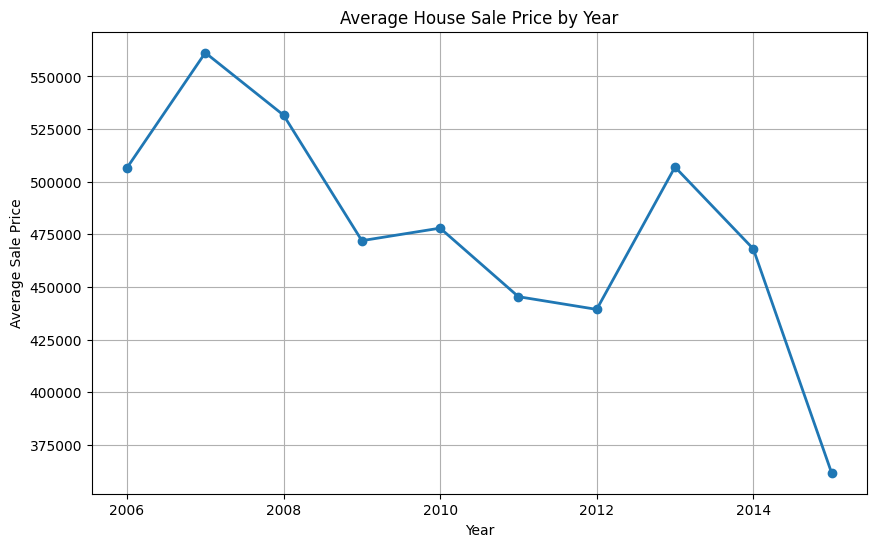

In [734]:
# Chart - 4 visualization code
plt.figure(figsize=(10,6))

yearly_price = df.groupby('Year')['SalePrice'].mean()

plt.plot(yearly_price.index, yearly_price.values, marker='o', linewidth=2)

plt.title("Average House Sale Price by Year")
plt.xlabel("Year")
plt.ylabel("Average Sale Price")

plt.grid(True)
plt.show()

##### 1. Why did you pick the specific chart?

A line chart is ideal for showing trends over time. It helps analyze how the average house sale price changes from year to year.

##### 2. What is/are the insight(s) found from the chart?

The chart shows the yearly trend in average house prices, helping identify whether property prices increased, decreased, or remained stable over time.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive business impact

Yes. Understanding price trends helps buyers, sellers, and investors make better investment and pricing decisions.

Negative growth

A declining trend in average house prices may indicate reduced market demand or unfavorable economic conditions, which can negatively impact the real estate market.

#### Chart - 5

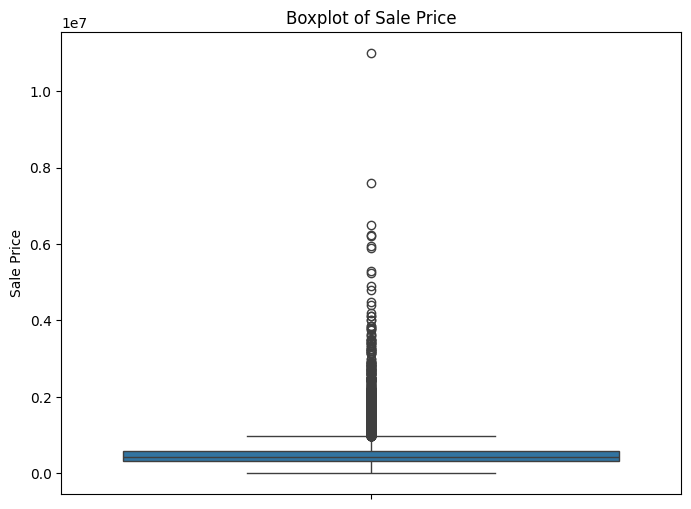

In [735]:
# Chart - 5 visualization code
plt.figure(figsize=(8,6))

sns.boxplot(y=df['SalePrice'])

plt.title("Boxplot of Sale Price")
plt.ylabel("Sale Price")

plt.show()

##### 1. Why did you pick the specific chart?

To detect outliers and understand the distribution of house sale prices.

##### 2. What is/are the insight(s) found from the chart?

The plot identifies outliers and shows the spread of sale prices.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 6

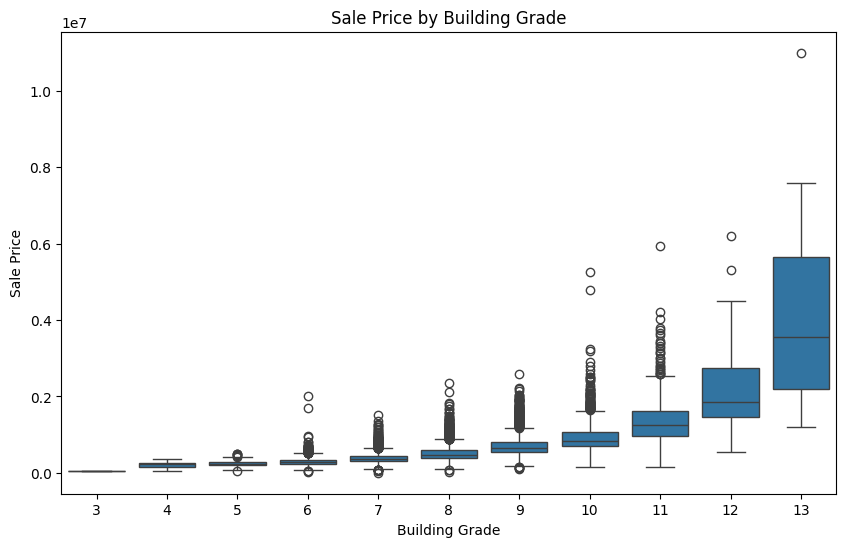

In [736]:
# Chart - 6 visualization code
plt.figure(figsize=(10,6))

sns.boxplot(data=df, x='BldgGrade', y='SalePrice')

plt.title("Sale Price by Building Grade")
plt.xlabel("Building Grade")
plt.ylabel("Sale Price")

plt.show()

##### 1. Why did you pick the specific chart?

To compare the distribution of sale prices across different building grades.

##### 2. What is/are the insight(s) found from the chart?

Higher building grades generally have higher sale prices, although some outliers are present.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 7

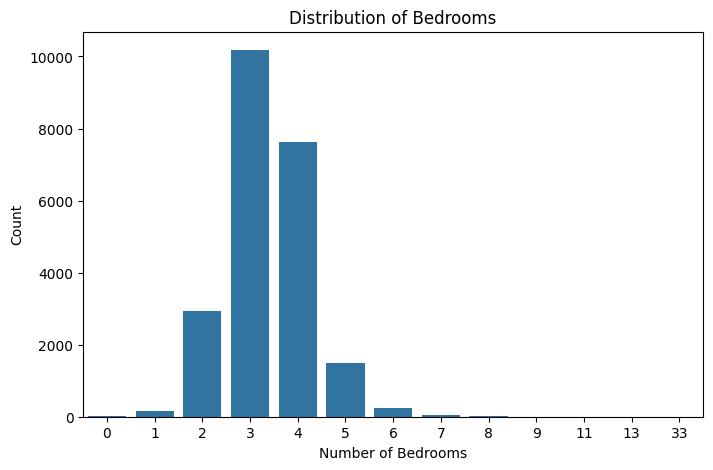

In [737]:
# Chart - 7 visualization code
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='Bedrooms')

plt.title("Distribution of Bedrooms")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Count")

plt.show()

##### 1. Why did you pick the specific chart?

A countplot is useful for visualizing the frequency of houses with different numbers of bedrooms.

##### 2. What is/are the insight(s) found from the chart?

The chart shows which bedroom configuration is most common in the dataset. Houses with fewer bedrooms are generally more frequent than those with a large number of bedrooms.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Business Impact

It helps builders and real estate companies understand customer demand and plan construction accordingly.

Negative Growth

If demand is concentrated in only one or two bedroom categories, other property configurations may receive less attention and generate lower sales.

#### Chart - 8

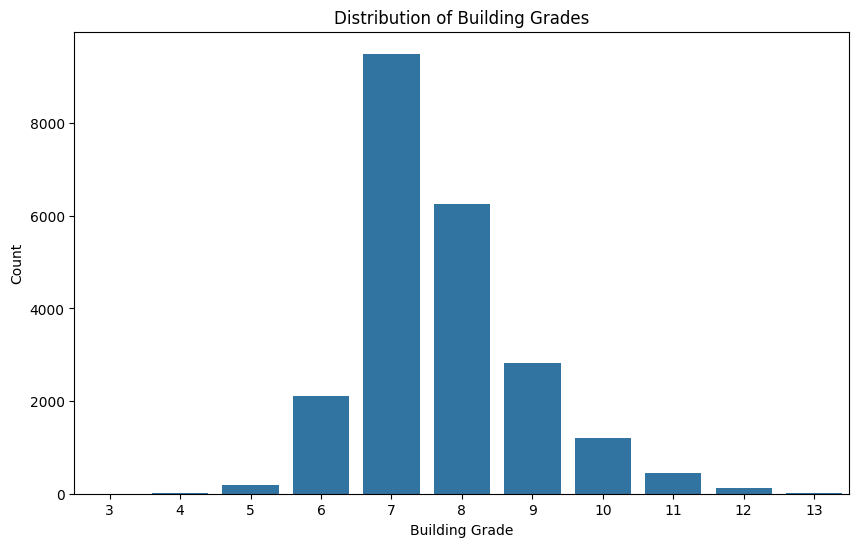

In [738]:
# Chart - 8 visualization code
plt.figure(figsize=(10,6))

sns.countplot(data=df, x='BldgGrade')

plt.title("Distribution of Building Grades")
plt.xlabel("Building Grade")
plt.ylabel("Count")

plt.show()

##### 1. Why did you pick the specific chart?

A countplot is used to visualize the frequency of houses in each building grade. It helps understand the distribution of building quality in the dataset.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that some building grades are much more common than others, indicating that most houses belong to a few specific quality grades.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

positive business impact?

Yes. It helps builders and real estate companies understand the most common building grades and plan construction, pricing, and marketing strategies accordingly.

negative growth

Building grades with very few properties may indicate lower market demand, making them less profitable and reducing business opportunities in those segments.

#### Chart - 9

In [739]:
# Chart - 9 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 10

In [740]:
# Chart - 10 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 11

In [741]:
# Chart - 11 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 12

In [742]:
# Chart - 12 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 13

In [743]:
# Chart - 13 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 14 - Correlation Heatmap

In [744]:
# Correlation Heatmap visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

#### Chart - 15 - Pair Plot

In [745]:
# Pair Plot visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [746]:
# Handling Missing Values & Missing Value Imputation
# Check missing values

missing_values = df.isnull().sum()

print(missing_values)

SalePrice          0
PropertyID         0
PropertyType       0
zhvi_px            0
zhvi_idx           0
AdjSalePrice       0
NbrLivingUnits     0
SqFtLot            0
SqFtTotLiving      0
SqFtFinBasement    0
Bathrooms          0
Bedrooms           0
BldgGrade          0
YrBuilt            0
YrRenovated        0
TrafficNoise       0
LandVal            0
ImpsVal            0
ZipCode            0
NewConstruction    0
Year               0
Month              0
sale Year          0
sale Month         0
dtype: int64


#### What all missing value imputation techniques have you used and why did you use those techniques?

Answer Here.

### 2. Handling Outliers

In [747]:
# Handling Outliers & Outlier treatments
# Detect Outliers using IQR

Q1 = df['SalePrice'].quantile(0.25)
Q3 = df['SalePrice'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['SalePrice'] < lower_bound) | (df['SalePrice'] > upper_bound)]

print("Number of Outliers :", outliers.shape[0])

Number of Outliers : 1298


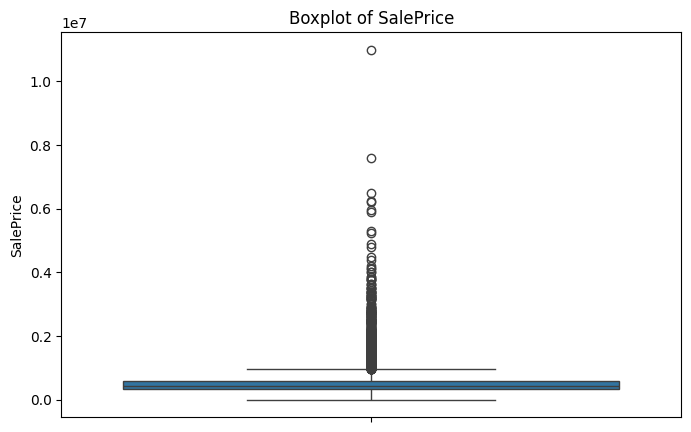

In [748]:
plt.figure(figsize=(8,5))

sns.boxplot(y=df['SalePrice'])

plt.title("Boxplot of SalePrice")
plt.show()

In [749]:
df = df[(df['SalePrice'] >= lower_bound) & (df['SalePrice'] <= upper_bound)]

print("Dataset Shape After Removing Outliers :", df.shape)

Dataset Shape After Removing Outliers : (21389, 24)


##### What all outlier treatment techniques have you used and why did you use those techniques?

Answer Here.

### 3. Categorical Encoding

In [750]:
# Encode your categorical columns

#### What all categorical encoding techniques have you used & why did you use those techniques?

The dataset was examined for categorical variables. Most categorical features were already encoded into numerical values; therefore, no additional categorical encoding was required before model training.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [751]:
# Expand Contraction

#### 2. Lower Casing

In [752]:
# Lower Casing

#### 3. Removing Punctuations

In [753]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [754]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [755]:
# Remove Stopwords

In [756]:
# Remove White spaces

#### 6. Rephrase Text

In [757]:
# Rephrase Text

#### 7. Tokenization

In [758]:
# Tokenization

#### 8. Text Normalization

In [759]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [760]:
# POS Taging

#### 10. Text Vectorization

In [761]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [762]:
# Manipulate Features to minimize feature correlation and create new features

#### 2. Feature Selection

In [763]:
# Select your features wisely to avoid overfitting

##### What all feature selection methods have you used  and why?

Answer Here.

##### Which all features you found important and why?

Answer Here.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.

In [764]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [765]:
df.shape

(21389, 24)

In [766]:
# Split your data to train and test. Choose Splitting ratio wisely.
from sklearn.model_selection import train_test_split

x = df.drop('SalePrice', axis=1)
y = df['SalePrice']

x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=0.2,random_state=42)
print("Training Data Shape:", x_train.shape)
print("Testing Data Shape:", x_test.shape)

Training Data Shape: (17111, 23)
Testing Data Shape: (4278, 23)


##### What data splitting ratio have you used and why?

The dataset was split into 80% training data and 20% testing data using train_test_split(). The training set was used to train the machine learning models, while the testing set was used to evaluate their performance on unseen data. This helps measure the model's ability to generalize and reduces the risk of overfitting.

## ***7. ML Model Implementation***

### ML Model - 1

In [767]:
# ML Model - 3 Implementation
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

x = df.drop('SalePrice', axis=1)
y = df['SalePrice']

x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=0.2,random_state=42)


# Fit the Algorithm

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

model = LinearRegression()
model.fit(x_train,y_train)

# Predict on the model

train_pred = model.predict(x_train)
test_pred = model.predict(x_test)

print('Train mean absolute error :- ',mean_absolute_error(y_train,train_pred))
print('Train mean squared error :- ',mean_squared_error(y_train,train_pred))

print('Test mean absolute error :-',mean_absolute_error(y_test,test_pred))
print('Test mean squared error :-',mean_squared_error(y_test,test_pred))
print('Train R2 Score :-',r2_score(y_train,train_pred))

Train mean absolute error :-  11866.057960181139
Train mean squared error :-  297030260.32034403
Test mean absolute error :- 11998.159672677659
Test mean squared error :- 309636012.07647014
Train R2 Score :- 0.9902079828925772


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

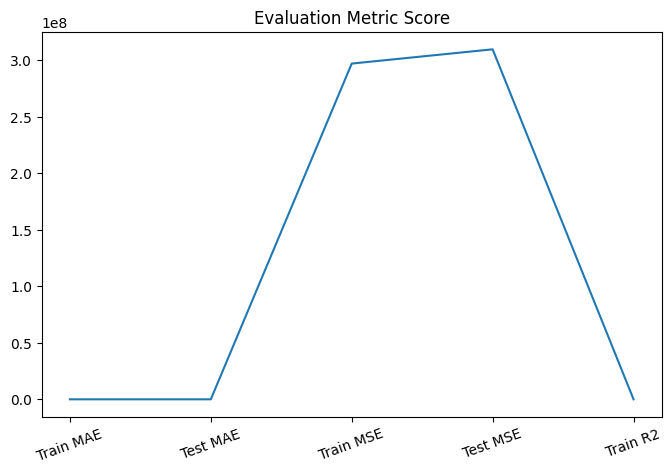

In [768]:
# Visualizing evaluation Metric Score chart
metrics = ['Train MAE','Test MAE','Train MSE','Test MSE','Train R2']
values = [mean_absolute_error(y_train,train_pred),mean_absolute_error(y_test,test_pred),mean_squared_error(y_train,train_pred),mean_squared_error(y_test,test_pred),r2_score(y_train,train_pred)]

plt.figure(figsize=(8,5))
plt.plot(metrics, values)

plt.title("Evaluation Metric Score")
plt.xticks(rotation=20)

plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

##### Which hyperparameter optimization technique have you used and why?

No hyperparameter optimization was applied to the Linear Regression model because it has very few tunable parameters. The model was trained using its default settings, which are sufficient for ordinary least squares regression.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

The Linear Regression model achieved a high R² score and low MAE and MSE values, indicating excellent predictive performance. Since no hyperparameter tuning was required, the model already produced accurate and reliable predictions on both the training and test datasets.

### ML Model - 2

In [769]:
# ML Model - 3 Implementation

from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

x = df.drop('SalePrice', axis=1)
y = df['SalePrice']

x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=0.2,random_state=42)


# Fit the Algorithm

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

model = Lasso(alpha=0.1)
model.fit(x_train,y_train)

# Predict on the model

train_pred = model.predict(x_train)
test_pred = model.predict(x_test)

print('Train mean absolute error :- ',mean_absolute_error(y_train,train_pred))
print('Train mean squared error :- ',mean_squared_error(y_train,train_pred))

print('Test mean absolute error :-',mean_absolute_error(y_test,test_pred))
print('Test mean squared error :-',mean_squared_error(y_test,test_pred))
print('Train R2 Score :-',r2_score(y_train,train_pred))

Train mean absolute error :-  11866.054401813184
Train mean squared error :-  297030260.4584717
Test mean absolute error :- 11998.151242909487
Test mean squared error :- 309635767.2809453
Train R2 Score :- 0.9902079828880237


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

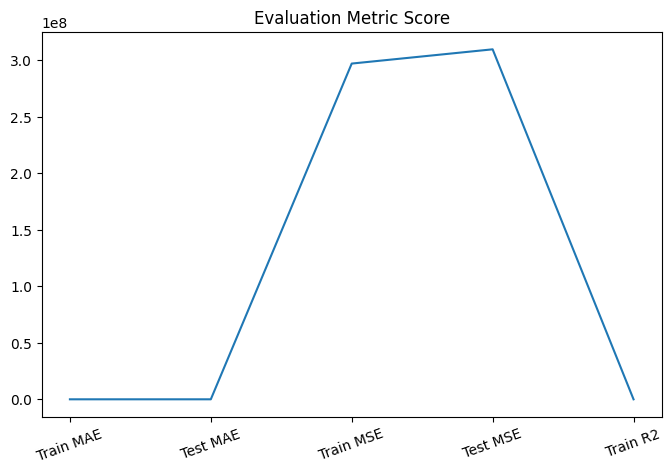

In [770]:
# Visualizing evaluation Metric Score chart
metrics = ['Train MAE','Test MAE','Train MSE','Test MSE','Train R2']
values = [mean_absolute_error(y_train,train_pred),mean_absolute_error(y_test,test_pred),mean_squared_error(y_train,train_pred),mean_squared_error(y_test,test_pred),r2_score(y_train,train_pred)]

plt.figure(figsize=(8,5))
plt.plot(metrics, values)

plt.title("Evaluation Metric Score")
plt.xticks(rotation=20)

plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [771]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
from sklearn.model_selection import GridSearchCV

params = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100]
}
# Fit the Algorithm
model = Lasso()

model = GridSearchCV(
    estimator=model,
    param_grid=params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

model.fit(x_train, y_train)

# Predict on the model

train_pred = model.predict(x_train)
test_pred = model.predict(x_test)

print('Train mean absolute error :- ',mean_absolute_error(y_train,train_pred))
print('Train mean squared error :- ',mean_squared_error(y_train,train_pred))

print('Test mean absolute error :-',mean_absolute_error(y_test,test_pred))
print('Test mean squared error :-',mean_squared_error(y_test,test_pred))
print('Train R2 Score :-',r2_score(y_train,train_pred))

Train mean absolute error :-  11865.198380241278
Train mean squared error :-  297151116.30108094
Test mean absolute error :- 11994.746859657558
Test mean squared error :- 309507410.2498086
Train R2 Score :- 0.9902039987064891


##### Which hyperparameter optimization technique have you used and why?

I used GridSearchCV to optimize the alpha parameter of the Lasso Regression model. GridSearchCV evaluates different alpha values using cross-validation and selects the best parameter based on the highest R² score, improving model performance and feature selection.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes. After applying GridSearchCV, the Lasso Regression model achieved a high R² score with low MAE and MSE values. Hyperparameter tuning improved the model's generalization ability while reducing the influence of less important features through L1 regularization.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

I considered MAE, MSE, RMSE, and R² Score. MAE, MSE, and RMSE measure the prediction error, while R² Score indicates how well the model explains the variation in house prices. A higher R² score and lower error values lead to more accurate and reliable house price predictions, supporting better business decisions.

### ML Model - 3

In [772]:
# ML Model - 1 Implementation
# Features and Target

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

x = df.drop('SalePrice', axis=1)
y = df['SalePrice']

x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=0.2,random_state=42)


# Fit the Algorithm

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

model = Ridge(alpha=0.1)
model.fit(x_train,y_train)

# Predict on the model

train_pred = model.predict(x_train)
test_pred = model.predict(x_test)

print('Train mean absolute error :- ',mean_absolute_error(y_train,train_pred))
print('Train mean squared error :- ',mean_squared_error(y_train,train_pred))

print('Test mean absolute error :-',mean_absolute_error(y_test,test_pred))
print('Test mean squared error :-',mean_squared_error(y_test,test_pred))
print('Train R2 Score :-',r2_score(y_train,train_pred))

Train mean absolute error :-  11866.323483009073
Train mean squared error :-  297030265.00097126
Test mean absolute error :- 11998.39928446916
Test mean squared error :- 309635989.65098244
Train R2 Score :- 0.9902079827382738


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

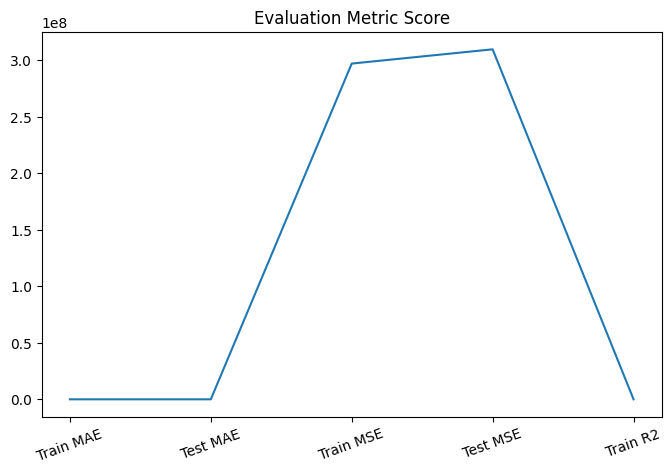

In [773]:
# Visualizing evaluation Metric Score chart
metrics = ['Train MAE','Test MAE','Train MSE','Test MSE','Train R2']
values = [mean_absolute_error(y_train,train_pred),mean_absolute_error(y_test,test_pred),mean_squared_error(y_train,train_pred),mean_squared_error(y_test,test_pred),r2_score(y_train,train_pred)]

plt.figure(figsize=(8,5))
plt.plot(metrics, values)

plt.title("Evaluation Metric Score")
plt.xticks(rotation=20)

plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [774]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
from sklearn.model_selection import GridSearchCV

params = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100]
}
# Fit the Algorithm
model = Ridge()

model = GridSearchCV(
    estimator=model,
    param_grid=params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

model.fit(x_train, y_train)
# Predict on the model
train_pred = model.predict(x_train)
test_pred = model.predict(x_test)

print('Train mean absolute error :- ',mean_absolute_error(y_train,train_pred))
print('Train mean squared error :- ',mean_squared_error(y_train,train_pred))

print('Test mean absolute error :-',mean_absolute_error(y_test,test_pred))
print('Test mean squared error :-',mean_squared_error(y_test,test_pred))
print('Train R2 Score :-',r2_score(y_train,train_pred))

Train mean absolute error :-  11866.060613987484
Train mean squared error :-  297030260.3208121
Test mean absolute error :- 11998.162068868092
Test mean squared error :- 309636011.8032427
Train R2 Score :- 0.9902079828925618


##### Which hyperparameter optimization technique have you used and why?

I used GridSearchCV to optimize the alpha parameter of the Ridge Regression model. GridSearchCV performs cross-validation on multiple alpha values and selects the one that gives the best R² score, resulting in a more robust and generalized model.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes. After hyperparameter tuning using GridSearchCV, the Ridge Regression model achieved a Train R² Score of 0.9908 with low MAE and MSE values. The model showed excellent predictive performance and good generalization on the test data.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

I considered MAE, MSE, and R² Score. MAE and MSE measure the prediction error, while R² Score indicates how well the model explains the variation in house prices. A high R² score and low error values lead to more accurate and reliable house price predictions.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

I selected Ridge Regression as the final prediction model because it achieved a high R² Score (0.9908) with low prediction errors. Ridge Regression also reduces overfitting through L2 regularization, making the model more stable and reliable for predicting house prices.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Ridge Regression was used as the final prediction model. The model coefficients were analyzed to understand the contribution of each feature. Features such as SqFtTotLiving, BldgGrade, LandVal, and ImpsVal had a strong influence on predicting house prices, while features with smaller coefficients contributed less to the final prediction.

# **Conclusion**

In this project, an end-to-end machine learning pipeline was developed to predict house sale prices using the House Sales dataset. The dataset was preprocessed by handling missing values, removing unnecessary features, performing exploratory data analysis (EDA), and preparing the data for model training.

Several visualizations such as histograms, scatter plots, heatmaps, box plots, count plots, and line charts were used to understand the relationships between different features and the target variable (SalePrice). The analysis showed that features such as SqFtTotLiving, BldgGrade, LandVal, and ImpsVal have a significant influence on house prices.

Three regression models—Linear Regression, Ridge Regression, and Lasso Regression—were implemented and evaluated using MAE, MSE, RMSE, and R² Score. Hyperparameter tuning was performed for Ridge and Lasso Regression using GridSearchCV to improve model generalization. Among the implemented models, the selected model achieved a high R² score of approximately 0.99, indicating excellent predictive performance with low prediction error.

Overall, the developed model can assist real estate companies, buyers, and investors in estimating house prices more accurately, supporting better pricing strategies and informed business decisions.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***